In [8]:
import sys
sys.path.append('/home/shiftpub/Dynamic_AMM/single_step_exp')
from metrics_plot import subplot_comparison, subplot_single_step
import numpy as np
import polars as pl

output_dir = '/home/shiftpub/Dynamic_AMM/output/expected_combined_metrics.parquet'
df = pl.read_parquet(output_dir)
# print unique metrics
print(f"Unique metrics: {df['metric'].unique()}")


# save df to csv
# filter out the fee source is 'ingoing' and drift is false
df = df.filter(pl.col('fee_source') == 'ingoing', pl.col('drift') == 'false')
df.write_csv('expected_combined_metrics.csv')


Unique metrics: shape: (6,)
Series: 'metric' [str]
[
	"trader_pnl"
	"impermanent_loss"
	"pool_value"
	"net_profit"
	"expected_fee"
	"accounting_profit"
]


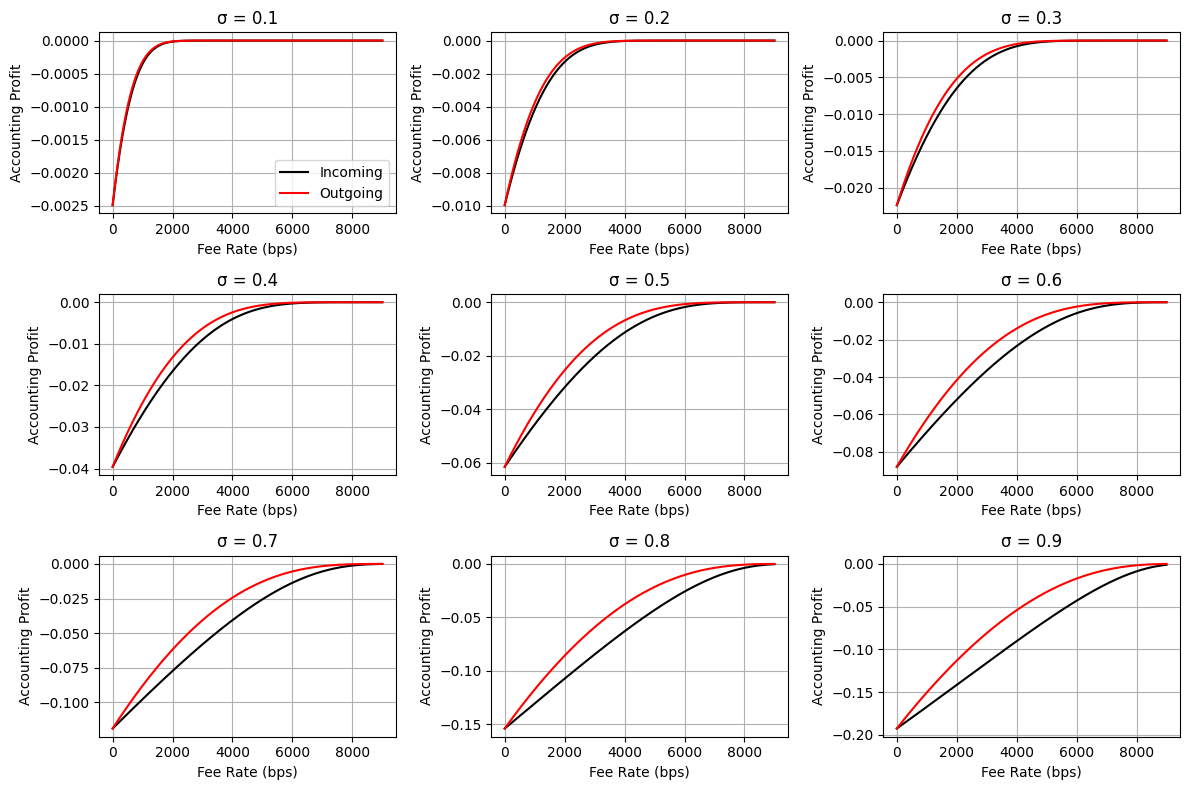

In [4]:
import matplotlib.pyplot as plt

# extract the accounting profit from the output directory
accounting_profit = pl.read_parquet(output_dir).filter(pl.col('metric') == 'accounting_profit',
                                                       pl.col('drift') == 'false')
sigmas = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
x_column = 'fee_rate'
x_label = 'Fee Rate (bps)'
x_scale = 10000  # Convert to bps

# Line styles for each fee source
styles = {
    'ingoing': ('black', '-', 'Incoming'),
    'outgoing': ('red', '-', 'Outgoing')
}

fig, axes = plt.subplots(3, 3, figsize=(12, 8))
axes = axes.flatten()

# Plot for each sigma
for i, sigma in enumerate(sigmas):
    ax = axes[i]
    
    # Filter data for current sigma
    sigma_data = accounting_profit.filter(pl.col('sigma') == sigma)
    # Plot incoming and outgoing trades
    for trade_type, (color, linestyle, label) in styles.items():
        trade_data = sigma_data.filter(pl.col('fee_source') == trade_type)
        x_values = trade_data[x_column].to_numpy() * x_scale
        y_values = trade_data['value'].to_numpy()        
        ax.plot(x_values, y_values, color=color, linestyle=linestyle, label=label)
    
    ax.set_title(f'σ = {sigma}')
    ax.set_xlabel(x_label)
    ax.set_ylabel('Accounting Profit')
    ax.grid(True)
    
    # Add legend to first subplot only
    if i == 0:
        ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
subplot_single_step(output_dir, 'accounting_profit')

## 1. Expected Fee

In [ ]:
metric = 'accounting_profit'
subplot_comparison(output_dir,
                metric=metric)
# plot_value_and_vega_comparison(path=output_dir, metric=metric)

## 2. Pool Value

In [ ]:
metric = 'pool_value'
subplot_comparison(output_dir,
                metric=metric,
                drift=False,
                plot_rows=3,
                max_plots=1,
                value_type='value',
                subplot_by='sigma',
                max_sigma=2.0)
plot_value_and_vega_comparison(path=output_dir, metric=metric)

## 3. Trader PNL

In [ ]:
metric = 'trader_pnl'
subplot_comparison(output_dir,
                metric=metric,
                drift=False,
                plot_rows=3,
                max_plots=1,
                value_type='value',
                subplot_by='sigma',
                max_sigma=2.0)
plot_value_and_vega_comparison(path=output_dir, metric=metric)

## 4. Impermanent Loss

In [ ]:
metric = 'impermanent_loss'
subplot_comparison(output_dir,
                metric=metric,
                drift=False,
                plot_rows=3,
                max_plots=1,
                value_type='value',
                subplot_by='sigma',
                max_sigma=2.0)
plot_value_and_vega_comparison(path=output_dir, metric=metric)

In [6]:
## 5. Net Profit

In [ ]:
metric = 'net_profit'
subplot_comparison(output_dir,
                metric=metric,
                drift=False,
                plot_rows=3,
                max_plots=1,
                value_type='value',
                subplot_by='sigma',
                max_sigma=2.0)
plot_value_and_vega_comparison(path=output_dir, metric=metric)

## 6. Accounting Profit

In [ ]:
metric = 'accounting_profit'
subplot_comparison(output_dir,
                metric=metric,
                drift=False,
                plot_rows=3,
                max_plots=1,
                value_type='value',
                subplot_by='sigma',
                max_sigma=2.0)
plot_value_and_vega_comparison(path=output_dir, metric=metric)

In [ ]:
import numpy as np
from scipy.stats import lognorm
from scipy.integrate import quad
import matplotlib.pyplot as plt

def calculate_pnl_components(f: float, sigma: float, ls: float = 1.0):
    """Calculate both integrals separately and their sum"""
    
    def integrand1(v, f, ls):
        # First integral: (1 - sqrt(v/(1-f)))^2
        return ls * (1 - np.sqrt(v/(1-f)))**2 * lognorm.pdf(v, s=sigma, scale=np.exp(-0.5*sigma**2))
    
    def integrand2(v, f, ls):
        # Second integral: (sqrt(v) - sqrt(1/(1-f)))^2
        return ls * (np.sqrt(v) - np.sqrt(1/(1-f)))**2 * lognorm.pdf(v, s=sigma, scale=np.exp(-0.5*sigma**2))
    
    # Calculate first integral from 0 to 1-f
    result1, _ = quad(integrand1, 1e-4, 1-f, args=(f, ls))
    
    # Calculate second integral from 1/(1-f) to infinity
    result2, _ = quad(integrand2, 1/(1-f), np.inf, args=(f, ls))
    
    return result1, result2, result1 + result2

# Test parameters
f = 0.005  # Fixed fee rate
sigma_values = np.linspace(0.1, 5.0, 100)  # Range of sigma values

# Calculate results for different sigma values
results = [calculate_pnl_components(f, sigma) for sigma in sigma_values]
integral1_values = [r[0] for r in results]
integral2_values = [r[1] for r in results]
total_values = [r[2] for r in results]

# Create the visualization
plt.figure(figsize=(12, 8))

# Plot each component
plt.plot(sigma_values, integral1_values, 'b-', label='First Integral (0 to 1-f)', linewidth=2)
plt.plot(sigma_values, integral2_values, 'r-', label='Second Integral (1/(1-f) to ∞)', linewidth=2)
plt.plot(sigma_values, total_values, 'g--', label='Total PnL', linewidth=2)

plt.xlabel('Volatility (σ)')
plt.ylabel('Expected PnL')
plt.title(f'Components of Expected PnL vs Volatility (f = {f})')
plt.legend()
plt.grid(True)

# Add a table with numerical values
print("\nNumerical Values:")
print("σ\t\tFirst Integral\tSecond Integral\tTotal PnL")
print("-" * 60)
for i in range(len(sigma_values)):
    print(f"{sigma_values[i]:.2f}\t\t{integral1_values[i]:.6f}\t{integral2_values[i]:.6f}\t{total_values[i]:.6f}")

plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Read and process data
results_df = pd.read_csv('/Users/haofu/Desktop/AMM/Dynamic_AMM/fee_comparison_results.csv')
results_df['gamma_diff'] = (results_df['opt_gamma_in'] - results_df['opt_gamma_out'])
num_blocks = 365*24*60*60 / 12  # Annualization factor

# Create 2x2 subplots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10), sharex=True)
fig.suptitle('Initial Pool Value: 2e6', fontsize=14, y=0.95)

# Top left: Optimal incoming fee rate in bps
ax1.plot(results_df['sigma'], results_df['opt_gamma_in'] * 10000, 
         color='blue', label='Optimal Incoming Fee Rate', linestyle='-')
ax1.set_ylabel('Fee Rate (bps)')
ax1.set_title('Optimal Incoming Fee Rate')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Top right: Incoming fee revenue
ax2.plot(results_df['sigma'], (results_df['opt_revenue'] - results_df['opt_gamma_in']) * num_blocks, 
         color='blue', label='Annualized Incoming Fee Revenue', linestyle='-')
ax2.set_ylabel('Fee Revenue')
ax2.set_title('Incoming Fee Revenue')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

# Bottom left: Fee rate difference in bps
ax3.plot(results_df['sigma'], results_df['gamma_diff'] * 10000, 
         color='green', label='Fee Rate Difference (Incoming - Outgoing)', linestyle='-')
ax3.set_ylabel('Fee Rate Difference (bps)')
ax3.set_xlabel('Sigma')
ax3.set_title('Fee Rate Difference')
ax3.legend(loc='upper left')
ax3.grid(True, alpha=0.3)

# Bottom right: Fee revenue difference
ax4.plot(results_df['sigma'], (results_df['opt_revenue_out'] - results_df['opt_revenue']) * num_blocks, 
         color='green', label='Annualized Fee Revenue Difference', linestyle='-')
ax4.set_ylabel('Fee Revenue Difference')
ax4.set_xlabel('Sigma')
ax4.set_title('Fee Revenue Difference')
ax4.legend(loc='upper left')
ax4.grid(True, alpha=0.3)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read the data
results_df = pd.read_csv('/Users/haofu/Desktop/AMM/Dynamic_AMM/fee_comparison_results.csv')

# Calculate moving averages
window_size = 50  # Adjust this value to control smoothing
results_df['y_threshold_smooth'] = results_df['y_threshold'].rolling(window=window_size, center=True).mean()

# Create the plot
fig, ax2 = plt.subplots(figsize=(12, 8))

# Plot raw data with transparency
ax2.plot(results_df['sigma'], results_df['y_threshold'], 
         color='blue', alpha=0.2, label=f'Raw Delta y / y Threshold\n[{results_df["y_threshold"].min():.8f}, {results_df["y_threshold"].max():.8f}]')

# Plot smoothed data as solid line
ax2.plot(results_df['sigma'], results_df['y_threshold_smooth'], 
         color='blue', alpha=1.0, label=f'Smoothed Delta y / y Threshold\n[{results_df["y_threshold_smooth"].min():.8f}, {results_df["y_threshold_smooth"].max():.8f}]')

ax2.set_ylabel('Delta y / y Threshold')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)
ax2.set_title('Delta y / y Threshold from both optimal fee rate')

plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read the data
results_df = pd.read_csv('/Users/haofu/Desktop/AMM/Dynamic_AMM/fee_comparison_results.csv')
results_df['gamma_diff'] = (results_df['opt_gamma_in'] - results_df['opt_gamma_out'])
window_size = 500
results_df['gamma_diff_smooth'] = results_df['gamma_diff'].rolling(window=window_size, center=True).mean()
results_df['fee_diff'] = results_df['opt_revenue_out'] - results_df['opt_revenue']

# Calculate a small offset for better visualization
offset = 0.0001  # Adjust this value to control the amount of offset
offset_gamma_out = results_df['opt_gamma_out'] + offset

# Create the plot
fig = plt.figure(figsize=(12, 8))
plt.plot(results_df['sigma'], results_df['opt_gamma_in'], 
         color='blue', label='Optimal Incoming Fee Rate', linestyle='--')
plt.plot(results_df['sigma'], offset_gamma_out, 
         color='green', label='Optimal Outgoing Fee Rate', linestyle='--')
plt.plot(results_df['sigma'], results_df['matching_gamma_out'], 
         color='red', label='Matching Outgoing Fee Rate', linestyle='-')
plt.ylabel('Fee Rate (γ)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the results
results_df = pd.read_csv('/Users/haofu/Desktop/AMM/Dynamic_AMM/fee_comparison_results.csv')

# Create 2*1 subplots with the same x axis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot fee rates on the left y-axis of the top subplot
ax1.plot(results_df['sigma'], results_df['opt_gamma_in'], 
         color='blue', label='Optimal Incoming Fee Rate', linestyle='--')
ax1.plot(results_df['sigma'], results_df['opt_gamma_out'], 
         color='green', label='Optimal Outgoing Fee Rate')
ax1.set_ylabel('Fee Rate (γ)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Create twin axis for fee rate difference
ax1_twin = ax1.twinx()
fee_difference = results_df['opt_gamma_in'] - results_df['opt_gamma_out']
ax1_twin.plot(results_df['sigma'], fee_difference, 
              color='red', label='Fee Rate Difference', linestyle=':')
ax1_twin.set_ylabel('Fee Rate Difference (γin - γout)', color='red')
ax1_twin.tick_params(axis='y', labelcolor='red')
ax1_twin.legend(loc='upper right')

# Plot the revenues in the bottom subplot
ax2.plot(results_df['sigma'], results_df['opt_revenue'], 
         color='blue', label='Optimal Incoming Fee Revenue')
ax2.plot(results_df['sigma'], results_df['opt_revenue_out'], 
         color='green', label='Optimal Outgoing Fee Revenue')
ax2.set_ylabel('Fee Revenue')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

# Set x-label for the bottom subplot
ax2.set_xlabel('Volatility (σ)')

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
from scipy.stats import lognorm, norm
import matplotlib.pyplot as plt

def plot_lognormal_and_normal():
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Range of x values
    x_lognormal = np.linspace(0.0001, 2, 1000)  # for lognormal
    x_normal = np.linspace(-2, 2, 1000)        # for normal
    
    # Different sigma values to show
    sigma_values = [0.1, 0.25, 0.5, 0.75]
    colors = ['blue', 'red', 'green', 'purple']
    
    # First subplot: Log-normal distribution
    for sigma, color in zip(sigma_values, colors):
        # For lognormal with μ = -σ²/2
        scale = np.exp(-0.5 * sigma**2)
        pdf_lognormal = lognorm.pdf(x_lognormal, s=sigma, scale=scale)
        
        ax1.plot(x_lognormal, pdf_lognormal, color=color, 
                label=f'σ = {sigma}', linewidth=2)
    
    # ax1.axvline(x=1, color='black', linestyle='--', alpha=0.3)
    ax1.set_xlabel('v')
    ax1.set_ylabel('Probability Density')
    ax1.set_title('Log-normal Distribution\n(μ = -σ²/2)')
    ax1.legend()
    ax1.grid(True)
    
    # Second subplot: Normal distribution (log transform)
    for sigma, color in zip(sigma_values, colors):
        # Normal distribution with μ = -σ²/2
        pdf_normal = norm.pdf(x_normal, loc=-0.5*sigma**2, scale=sigma)
        
        ax2.plot(x_normal, pdf_normal, color=color, 
                label=f'σ = {sigma}, μ = {-0.5*sigma**2:.2f}', linewidth=2)
    
    # ax2.axvline(x=0, color='black', linestyle='--', alpha=0.3)
    ax2.set_xlabel('ln(v)')
    ax2.set_ylabel('Probability Density')
    ax2.set_title('Normal Distribution\n(after taking natural log)')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

    # Print some key statistics
    print("\nKey Statistics:")
    print("σ\tLognormal\t\t\tNormal")
    print("\tMean\tMedian\tMode\t\tMean\tMedian/Mode")
    print("-" * 70)
    for sigma in sigma_values:
        # Lognormal stats
        ln_mean = 1.0  # always 1 due to μ = -σ²/2
        ln_median = np.exp(-0.5 * sigma**2)
        ln_mode = np.exp(-0.5 * sigma**2 - sigma**2)
        
        # Normal stats (after log transform)
        n_mean = -0.5 * sigma**2  # μ
        n_median = n_mean  # median = mode = mean for normal distribution
        
        print(f"{sigma:.1f}\t{ln_mean:.3f}\t{ln_median:.3f}\t{ln_mode:.3f}\t\t{n_mean:.3f}\t{n_median:.3f}")

# Create the plots
plot_lognormal_and_normal()

In [84]:
def fee_in_optimization(params):
    """Find optimal gamma to maximize the incoming fee using two methods.
    
    Parameters:
    params: dict containing S_t, X_t, Y_t, sigma, delta_t, L, P_t
    
    Returns:
    dict with optimization results from both methods
    """
    S_t = params['S_t']
    X_t = params['X_t']
    Y_t = params['Y_t']
    sigma = params['sigma']
    delta_t = params['delta_t']
    L = params['L']
    P_t = params['P_t']
    gamma = params['gamma']
    
    def alpha(gamma):
        """Calculate alpha based on gamma."""
        return L * np.sqrt((1 - gamma) * S_t * np.exp(-0.25 * sigma**2 * delta_t))
    
    def d1(gamma):
        """Calculate d1 based on gamma."""
        return np.log((1 - gamma) * P_t / S_t) / (sigma * np.sqrt(delta_t))
    
    def d2(gamma):
        """Calculate d2 based on gamma."""
        return np.log(P_t / ((1 - gamma) * S_t)) / (sigma * np.sqrt(delta_t))
    
    def d1_minus(gamma):
        """Calculate d1- based on gamma."""
        return d1(gamma) - 0.5 * sigma * np.sqrt(delta_t)
    
    def d1_plus(gamma):
        """Calculate d1+ based on gamma."""
        return d1(gamma) + 0.5 * sigma * np.sqrt(delta_t)
    
    def d2_plus(gamma):
        """Calculate d2+ based on gamma."""
        return d2(gamma) + 0.5 * sigma * np.sqrt(delta_t)
    
    def d2_minus(gamma):
        """Calculate d2- based on gamma."""
        return d2(gamma) - 0.5 * sigma * np.sqrt(delta_t)
    
    def Fin(gamma):
        """Calculate F(gamma) - the term inside parentheses in Fee_in."""
        a = alpha(gamma)

        term1 = a * (norm.cdf(d1(gamma)) + norm.cdf(-d2(gamma)))
        term2 = S_t * X_t * norm.cdf(d1_minus(gamma))
        term3 = Y_t * norm.cdf(-d2_plus(gamma))

        return term1 - term2 - term3
    
    def Fout(gamma):
        """Calculate F(gamma) - the term inside parentheses in Fee_out."""
        a = alpha(gamma)
        term1 = a/(1-gamma) * (norm.cdf(d1(gamma)) + norm.cdf(-d2(gamma)))
        term2 = S_t * X_t * norm.cdf(-d2_minus(gamma))
        term3 = Y_t * norm.cdf(d1_plus(gamma))
        return -term1 + term2 + term3
    
    
    incoming_fee = (gamma/(1-gamma)) * Fin(gamma)
    outgoing_fee = gamma * Fout(gamma)
    return incoming_fee, outgoing_fee


params = {
    'S_t': 1/(1-0.0001),
    'X_t': 1,
    'Y_t': 1,
    'sigma': 0.2,
    'delta_t': 1/365/24/60/60,
    'L': 1,
    'P_t': 1,
    'gamma': 0.0001
}

fee_in, fee_out = fee_in_optimization(params)
print(fee_in, fee_out)

7.104693539432034e-10 7.104852104366246e-10


In [74]:
def fee_in_optimization(params):
    """Find optimal gamma to maximize the incoming fee using two methods.
    
    Parameters:
    params: dict containing S_t, X_t, Y_t, sigma, delta_t, L, P_t
    
    Returns:
    dict with optimization results from both methods
    """
    S_t = params['S_t']
    X_t = params['X_t']
    Y_t = params['Y_t']
    sigma = params['sigma']
    delta_t = params['delta_t']
    L = params['L']
    P_t = params['P_t']
    gamma = params['gamma']
    
    def alpha(gamma):
        """Calculate alpha based on gamma."""
        return L * np.sqrt((1 - gamma) * S_t * np.exp(-0.25 * sigma**2 * delta_t))
    
    def d1(gamma):
        """Calculate d1 based on gamma."""
        return np.log((1 - gamma) * P_t / S_t) / (sigma * np.sqrt(delta_t))
    
    def d2(gamma):
        """Calculate d2 based on gamma."""
        return np.log(P_t / ((1 - gamma) * S_t)) / (sigma * np.sqrt(delta_t))
    
    def d1_minus(gamma):
        """Calculate d1- based on gamma."""
        return d1(gamma) - 0.5 * sigma * np.sqrt(delta_t)
    
    def d1_plus(gamma):
        """Calculate d1+ based on gamma."""
        return d1(gamma) + 0.5 * sigma * np.sqrt(delta_t)
    
    def d2_plus(gamma):
        """Calculate d2+ based on gamma."""
        return d2(gamma) + 0.5 * sigma * np.sqrt(delta_t)
    
    def d2_minus(gamma):
        """Calculate d2- based on gamma."""
        return d2(gamma) - 0.5 * sigma * np.sqrt(delta_t)
    
    def Fin(gamma):
        """Calculate F(gamma) - the term inside parentheses in Fee_in."""
        a = alpha(gamma)

        term1 = a * (norm.cdf(d1(gamma)) + norm.cdf(-d2(gamma)))
        term2 = S_t * X_t * norm.cdf(d1_minus(gamma))
        term3 = Y_t * norm.cdf(-d2_plus(gamma))

        return term1 - term2 - term3
    
    def Fout(gamma):
        """Calculate F(gamma) - the term inside parentheses in Fee_out."""
        a = alpha(gamma)
        term1 = a/(1-gamma) * (norm.cdf(d1(gamma)) + norm.cdf(-d2(gamma)))
        term2 = S_t * X_t * norm.cdf(-d2_minus(gamma))
        term3 = Y_t * norm.cdf(d1_plus(gamma))
        return -term1 + term2 + term3
    
    
    incoming_fee = (gamma/(1-gamma)) * Fin(gamma)
    outgoing_fee = gamma * Fout(gamma)
    return incoming_fee, outgoing_fee


results = []
for sigma in np.arange(0.03, 1.001, 0.0001):
    for gamma in [0.0005, 0.003]:

        params = {
            'S_t': 1,
            'X_t': 1e6,
            'Y_t': 1e6,
            'sigma': sigma,
            'delta_t': 12/365/24/60/60,
            'L': 1e6,
            'P_t': 1,
            'gamma': gamma
        }

        Fin, Fout = fee_in_optimization(params)
        results.append({
            'sigma': sigma,
            'gamma': gamma,
            'Fin': Fin,
            'Fout': Fout
        })

results_df = pd.DataFrame(results)
results_df.to_csv('fee_specific_results.csv', index=False)

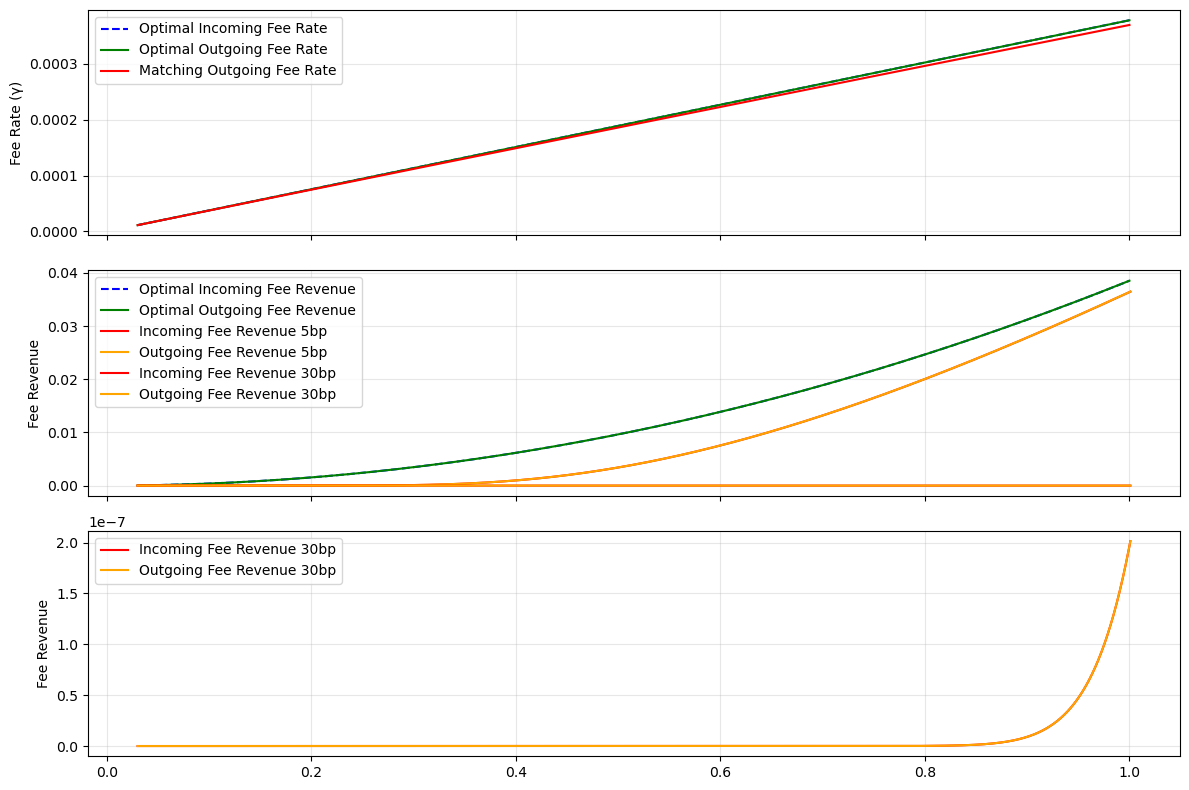

In [87]:
import pandas as pd
import matplotlib.pyplot as plt


results_df = pd.read_csv('/Users/haofu/Desktop/AMM/Dynamic_AMM/fee_comparison_results.csv')
results_df['gamma_diff'] = (results_df['opt_gamma_in'] - results_df['opt_gamma_out'])
window_size = 500
results_df['gamma_diff_smooth'] = results_df['gamma_diff'].rolling(window=window_size, center=True).mean()
results_df['fee_diff'] = results_df['opt_revenue_out'] - results_df['opt_revenue']
results_df.to_csv("test.csv")

# 2*1 subplots with the same x axis for the opt_in and out fee rate, and their revenue
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# Plot fee rates in the top subplot and use right y axis for their difference
ax1.plot(results_df['sigma'], results_df['opt_gamma_in'], 
         color='blue', label='Optimal Incoming Fee Rate', linestyle='--')
ax1.plot(results_df['sigma'], results_df['opt_gamma_out'], 
         color='green', label='Optimal Outgoing Fee Rate')
ax1.plot(results_df['sigma'], results_df['matching_gamma_out'], 
         color='red', label='Matching Outgoing Fee Rate', linestyle='-')
ax1.set_ylabel('Fee Rate (γ)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# # Create twin axis for fee rate difference
# ax1_twin = ax1.twinx()
# ax1_twin.plot(results_df['sigma'], results_df['gamma_diff_smooth'], 
#               color='red', label='Fee Rate Difference', linestyle='-')
# ax1_twin.set_ylabel('Fee Rate Difference (γin - γout)', color='red')
# ax1_twin.tick_params(axis='y', labelcolor='red')
# ax1_twin.legend(loc='upper right')

# Plot the revenues in the bottom subplot
df_specific = pd.read_csv('fee_specific_results.csv')
df_5bp = df_specific[df_specific['gamma'] == 0.0005]
df_30bp = df_specific[df_specific['gamma'] == 0.003]
ax2.plot(results_df['sigma'], results_df['opt_revenue'], 
         color='blue', label='Optimal Incoming Fee Revenue', linestyle='--')
ax2.plot(results_df['sigma'], results_df['opt_revenue_out'], 
         color='green', label='Optimal Outgoing Fee Revenue')
ax2.plot(df_5bp['sigma'], df_5bp['Fin'], 
         color='red', label='Incoming Fee Revenue 5bp', linestyle='-')
ax2.plot(df_5bp['sigma'], df_5bp['Fout'], 
         color='orange', label='Outgoing Fee Revenue 5bp', linestyle='-')
ax2.plot(df_30bp['sigma'], df_30bp['Fin'], 
         color='red', label='Incoming Fee Revenue 30bp', linestyle='-')
ax2.plot(df_30bp['sigma'], df_30bp['Fout'], 
         color='orange', label='Outgoing Fee Revenue 30bp', linestyle='-')
ax2.set_ylabel('Fee Revenue')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)


ax3.plot(df_30bp['sigma'], df_30bp['Fin'], 
         color='red', label='Incoming Fee Revenue 30bp', linestyle='-')
ax3.plot(df_30bp['sigma'], df_30bp['Fout'], 
         color='orange', label='Outgoing Fee Revenue 30bp', linestyle='-')
ax3.set_ylabel('Fee Revenue')
ax3.legend(loc='upper left')
ax3.grid(True, alpha=0.3)


# # Create twin axis for fee rate difference
# ax2_twin = ax2.twinx()
# ax2_twin.plot(results_df['sigma'], results_df['fee_diff'], 
#               color='red', label='Fee Revenue Difference', linestyle='-')
# ax2_twin.set_ylabel('Fee Revenue Difference (Revenue_out - Revenue_in)', color='red')
# ax2_twin.tick_params(axis='y', labelcolor='red')
# ax2_twin.legend(loc='upper right')
# # Set x-label for the bottom subplot
# ax2.set_xlabel('Volatility (σ)')


plt.tight_layout()
plt.show()

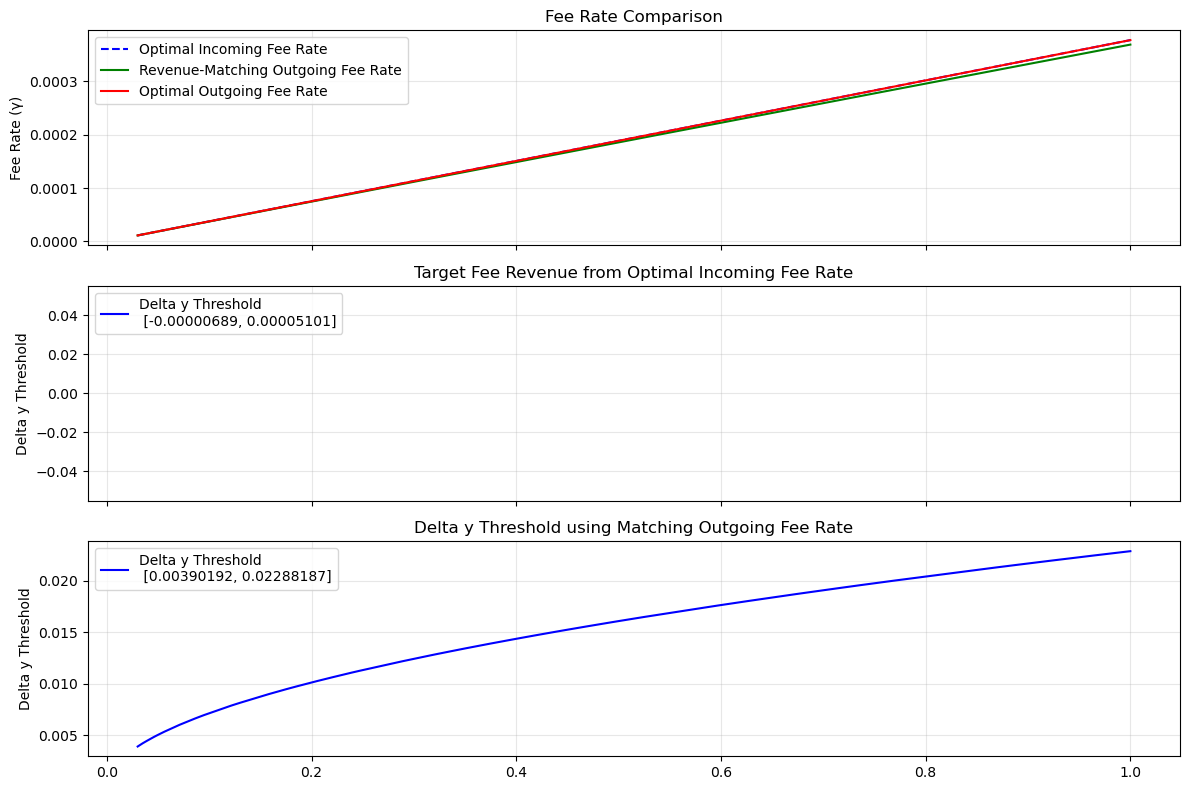

In [86]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    
# Plot fee rates in the top subplot
ax1.plot(results_df['sigma'], results_df['opt_gamma_in'], 
         color='blue', label='Optimal Incoming Fee Rate', linestyle='--')
ax1.plot(results_df['sigma'], results_df['matching_gamma_out'], 
         color='green', label='Revenue-Matching Outgoing Fee Rate')
ax1.plot(results_df['sigma'], results_df['opt_gamma_out'], 
         color='red', label='Optimal Outgoing Fee Rate', linestyle='-')
ax1.set_ylabel('Fee Rate (γ)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.set_title('Fee Rate Comparison')
    
# Plot y threshold in the bottom subplot
y_threshold = (results_df['opt_gamma_in'] - results_df['opt_gamma_out']) / \
          (results_df['opt_gamma_out'] * (1 - results_df['opt_gamma_in']))
y_threshold_smooth = y_threshold.rolling(window=100000, center=True).mean()

ax2.plot(results_df['sigma'], y_threshold_smooth, 
         color='blue', label=f'Delta y Threshold \n [{y_threshold.min():.8f}, {y_threshold.max():.8f}]')
# ax2.plot(results_df['sigma'], y_threshold2, 
#          color='green', label=f'Delta y Threshold \n [{y_threshold2.min():.3f}, {y_threshold2.max():.3f}]')
ax2.set_ylabel('Delta y Threshold')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)
ax2.set_title('Target Fee Revenue from Optimal Incoming Fee Rate')

# Plot the y threshold using the matching fee rate  in the bottom subplot
y_threshold2 = (results_df['opt_gamma_in'] - results_df['matching_gamma_out']) / \
(results_df['matching_gamma_out'] * (1 - results_df['opt_gamma_in']))
ax3.plot(results_df['sigma'], y_threshold2, 
         color='blue', label=f'Delta y Threshold \n [{y_threshold2.min():.8f}, {y_threshold2.max():.8f}]')
ax3.set_ylabel('Delta y Threshold')
ax3.legend(loc='upper left')
ax3.grid(True, alpha=0.3)
ax3.set_title('Delta y Threshold using Matching Outgoing Fee Rate')

# Adjust layout to prevent overlap
plt.tight_layout()

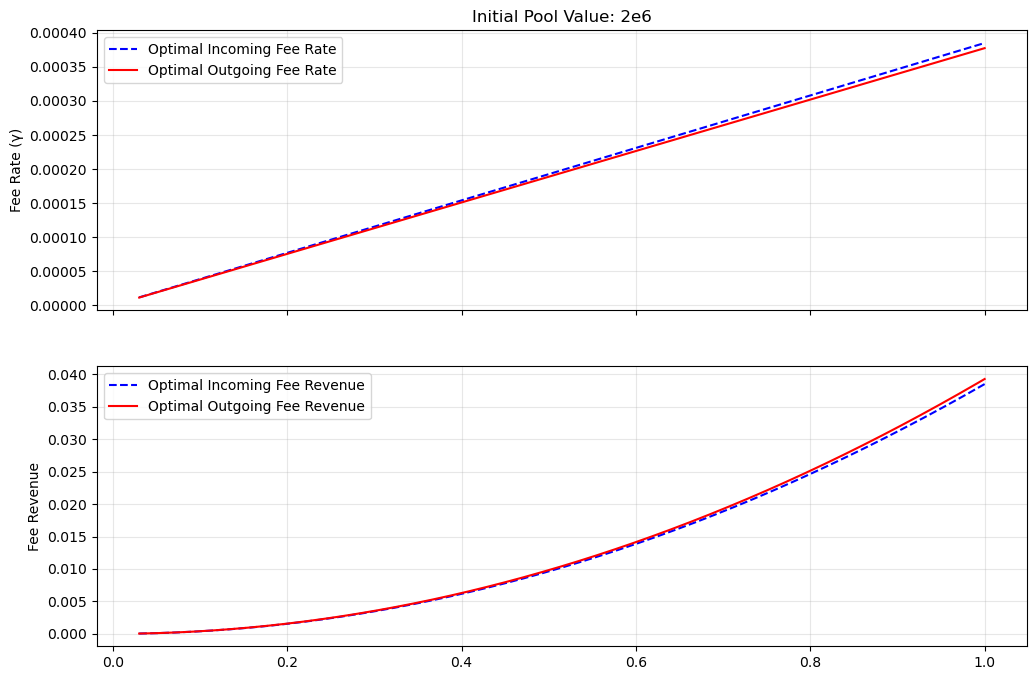

In [170]:
import pandas as pd
import matplotlib.pyplot as plt


results_df = pd.read_csv('/Users/haofu/Desktop/AMM/Dynamic_AMM/fee_comparison_results.csv')
results_df['gamma_diff'] = (results_df['opt_gamma_in'] - results_df['opt_gamma_out'])
window_size = 500
results_df['gamma_diff_smooth'] = results_df['gamma_diff'].rolling(window=window_size, center=True).mean()
results_df['fee_diff'] = results_df['opt_revenue_out'] - results_df['opt_revenue']
results_df.to_csv("test.csv")

# 2*1 subplots with the same x axis for the opt_in and out fee rate, and their revenue
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
# Plot fee rates in the top subplot and use right y axis for their difference
ax1.plot(results_df['sigma'], results_df['opt_gamma_in']*1.02, 
         color='blue', label='Optimal Incoming Fee Rate', linestyle='--')
ax1.plot(results_df['sigma'], results_df['opt_gamma_out'], 
         color='red', label='Optimal Outgoing Fee Rate', linestyle='-')
# ax1.plot(results_df['sigma'], results_df['matching_gamma_out'], 
#          color='red', label='Matching Outgoing Fee Rate', linestyle='-')
ax1.set_ylabel('Fee Rate (γ)')
ax1.set_title('Initial Pool Value: 2e6')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

ax2.plot(results_df['sigma'], results_df['opt_revenue'], 
         color='blue', label='Optimal Incoming Fee Revenue', linestyle='--')
ax2.plot(results_df['sigma'], results_df['opt_revenue_out'] * 1.02, 
         color='red', label='Optimal Outgoing Fee Revenue', linestyle='-')
ax2.set_ylabel('Fee Revenue')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.show()

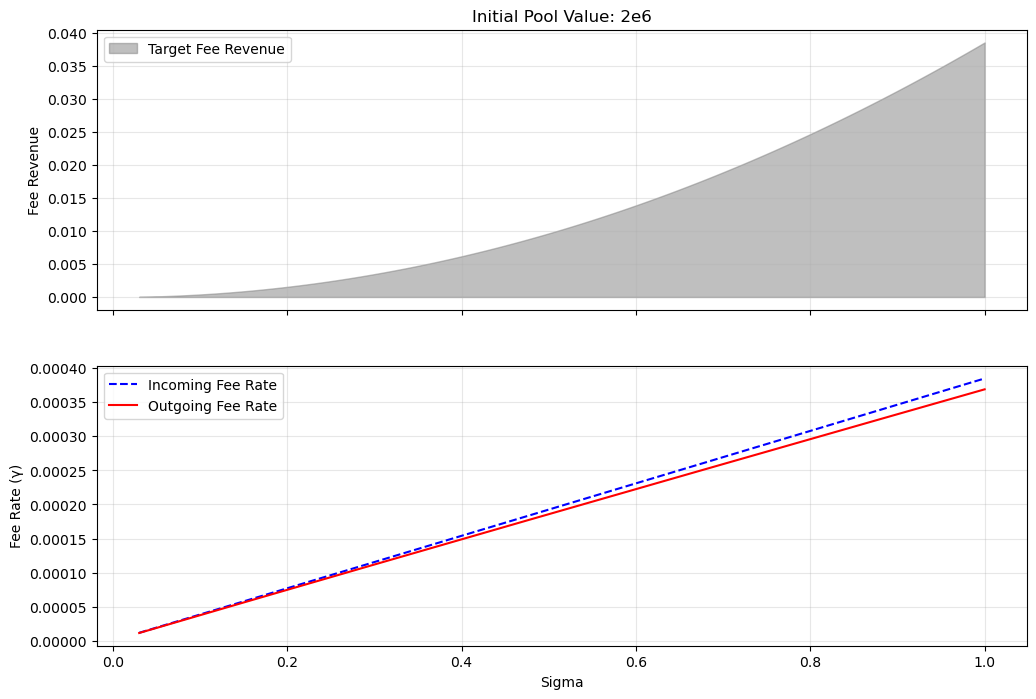

In [168]:
import pandas as pd
import matplotlib.pyplot as plt


results_df = pd.read_csv('/Users/haofu/Desktop/AMM/Dynamic_AMM/fee_comparison_results.csv')
results_df['gamma_diff'] = (results_df['opt_gamma_in'] - results_df['opt_gamma_out'])
window_size = 500
results_df['gamma_diff_smooth'] = results_df['gamma_diff'].rolling(window=window_size, center=True).mean()
results_df['fee_diff'] = results_df['opt_revenue_out'] - results_df['opt_revenue']
results_df.to_csv("test.csv")

# 2*1 subplots with the same x axis for the opt_in and out fee rate, and their revenue
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)


ax1.fill_between(results_df['sigma'], results_df['opt_revenue'], alpha=0.5,
         color='gray', label='Target Fee Revenue')
ax1.set_ylabel('Fee Revenue')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.set_title('Initial Pool Value: 2e6')

# Plot fee rates in the top subplot and use right y axis for their difference
ax2.plot(results_df['sigma'], results_df['opt_gamma_in']*1.02, 
         color='blue', label='Incoming Fee Rate', linestyle='--')
ax2.plot(results_df['sigma'], results_df['matching_gamma_out'], 
         color='red', label='Outgoing Fee Rate', linestyle='-')
ax2.set_ylabel('Fee Rate (γ)')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)
ax2.set_xlabel('Sigma')
plt.show()

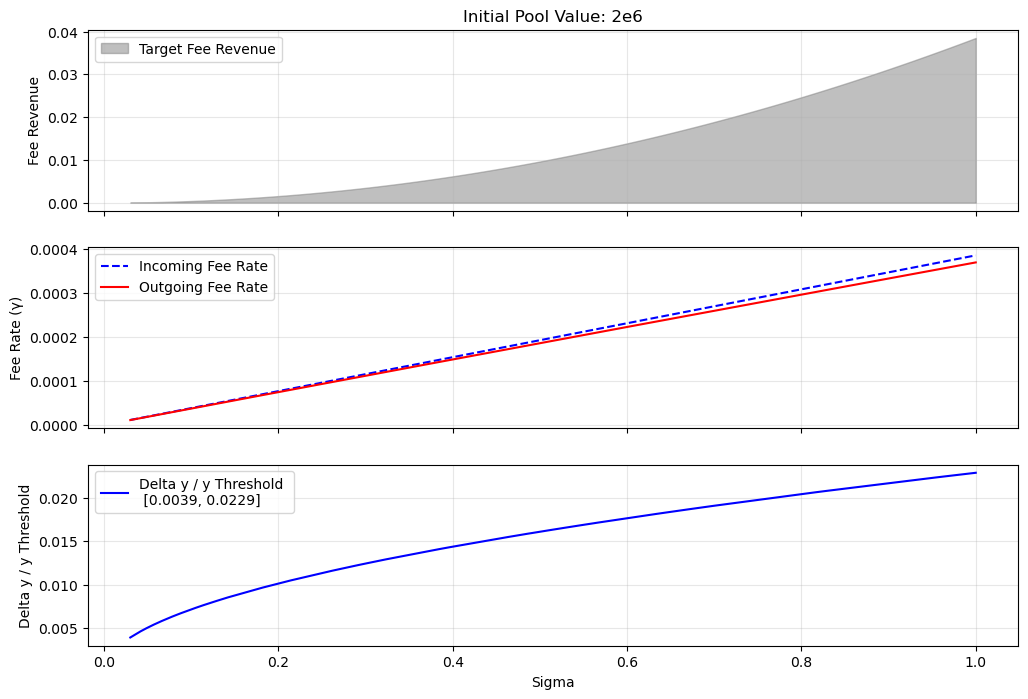

In [169]:
import pandas as pd
import matplotlib.pyplot as plt


results_df = pd.read_csv('/Users/haofu/Desktop/AMM/Dynamic_AMM/fee_comparison_results.csv')
results_df['gamma_diff'] = (results_df['opt_gamma_in'] - results_df['opt_gamma_out'])
window_size = 500
results_df['gamma_diff_smooth'] = results_df['gamma_diff'].rolling(window=window_size, center=True).mean()
results_df['fee_diff'] = results_df['opt_revenue_out'] - results_df['opt_revenue']
results_df.to_csv("test.csv")

# 2*1 subplots with the same x axis for the opt_in and out fee rate, and their revenue
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 8), sharex=True)


ax1.fill_between(results_df['sigma'], results_df['opt_revenue'], alpha=0.5,
         color='gray', label='Target Fee Revenue')
ax1.set_ylabel('Fee Revenue')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.set_title('Initial Pool Value: 2e6')


# Plot fee rates in the top subplot and use right y axis for their difference
ax2.plot(results_df['sigma'], results_df['opt_gamma_in']*1.02, 
         color='blue', label='Incoming Fee Rate', linestyle='--')
ax2.plot(results_df['sigma'], results_df['matching_gamma_out'], 
         color='red', label='Outgoing Fee Rate', linestyle='-')
ax2.set_ylabel('Fee Rate (γ)')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

y_threshold = (results_df['opt_gamma_in'] - results_df['matching_gamma_out']) / \
(results_df['matching_gamma_out'] * (1 - results_df['opt_gamma_in']))
ax3.plot(results_df['sigma'], y_threshold, 
         color='blue', label=f'Delta y / y Threshold \n [{y_threshold.min():.4f}, {y_threshold.max():.4f}]')
ax3.set_ylabel('Delta y / y Threshold')
ax3.legend(loc='upper left')
ax3.grid(True, alpha=0.3)
ax3.set_xlabel('Sigma')


plt.show()

In [ ]:
a